In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textwrap import fill

#load the Lookup data/lookup_oa2022_lsoa11_EW.csv
oa_lsoa = pd.read_csv('../data/lookup_oa2022_lsoa11_EW.csv')
#rename columns
oa_lsoa.columns = ['OA','LSOA']

# ni = pd.read_excel('../data/geography-data-zone-and-super-data-zone-lookups.xlsx',sheet_name='DZ2021_lookup')
# ni = ni[['DZ2021_code','SDZ2021_code']]
# ni.columns = ['OA','LSOA']
# #concatenate
# oa_lsoa = pd.concat([oa_lsoa,ni])

oa_lsoa.set_index('OA',inplace=True)

imd = pd.read_csv('../data/uk_imd2019.csv')
imd = imd[["LSOA","SOA_decile"]]
imd.columns = ['LSOA','IMD']

#density 
density = pd.read_csv('../data/eng_raw_csvs/ts006.csv')
#rename ts006001 to density
density.columns = ['OA','Density']
#calculate deciles
density['Density_decile'] = pd.qcut(density['Density'],10,labels=False)
#reverse deciles
density['Density_decile'] = 10 - density['Density_decile']
#drop density
density.drop('Density',axis=1,inplace=True)
#set index as OA
density.set_index('OA',inplace=True)


cleaned_data_path = "../data/engcensus_cleaned_scaled.parquet"
data = pd.read_parquet(cleaned_data_path)
data.set_index('OA',inplace=True)
# Ensure OA is a column, not just an index


reco_err = pd.DataFrame()
pca_reco_err = pd.DataFrame()

In [2]:
bottleneck = 64


reco_path = f"../engcensus/60epoch_scan_alleng_lin/census_geodemo__bottleneck_{bottleneck}_v1__reconstructed_outputs.csv"
reco_data = pd.read_csv(reco_path, index_col=0)

# Load PCA reconstruction data
pca_path = f"../data/PCA_unscaled/{bottleneck}_components.csv"
pca_reco = pd.read_csv(pca_path, index_col=0)

In [ ]:
# for bottleneck in [2, 4, 8, 16, 32, 64, 128, 200]:
#     print(f"Processing bottleneck: {bottleneck}")
#     # Load reconstructed autoencoder data
#     reco_path = f"../engcensus/200epoch_scan_alleng_lin/census_geodemo__bottleneck_{bottleneck}_v1__reconstructed_outputs.csv"
#     reco_data = pd.read_csv(reco_path, index_col=0)

#     # Load PCA reconstruction data
#     pca_path = f"../data/PCA_unscaled/{bottleneck}_components.csv"
#     pca_reco = pd.read_csv(pca_path, index_col=0)

#     # Compute reconstruction errors
#     ae_err = np.abs(data.set_index("OA") - reco_data).mean(axis=1).reset_index()
#     pca_err = np.abs(data.set_index("OA") - pca_reco).mean(axis=1).reset_index()

    
#     # Rename columns
#     ae_err = ae_err.rename(columns={0: f"reco_err_{bottleneck}"})
#     pca_err = pca_err.rename(columns={0: f"pca_err_{bottleneck}"})
#     # Normalize errors
    
#     ae_err[f"reco_err_{bottleneck}_norm"] = ae_err[f"reco_err_{bottleneck}"] / ae_err[f"reco_err_{bottleneck}"].mean() * 100
#     pca_err[f"pca_err_{bottleneck}_norm"] = pca_err[f"pca_err_{bottleneck}"] / pca_err[f"pca_err_{bottleneck}"].mean() * 100

#     # Merge into final DataFrames
#     if reco_err.empty:
#         reco_err = ae_err
#         pca_reco_err = pca_err
#     else:
#         reco_err = reco_err.merge(ae_err, on="OA")
#         pca_reco_err = pca_reco_err.merge(pca_err, on="OA")

In [ ]:
reco_err_var = np.abs(data - reco_data).mean(axis=0)

In [7]:
reco_err_var.mean()

np.float64(0.00943780563222659)

In [10]:
data.mean(axis=0)

ts0010002_PCT    0.988467
ts0010003_PCT    0.011533
ts0020002_PCT    0.375132
ts0020003_PCT    0.444849
ts0020004_PCT    0.442699
                   ...   
ts0750003_PCT    0.018610
ts0750004_PCT    0.329457
ts0750005_PCT    0.203076
ts0750006_PCT    0.137195
ts0750007_PCT    0.011826
Length: 429, dtype: float64

In [6]:
reco_err_var

ts0010002_PCT    0.005884
ts0010003_PCT    0.004726
ts0020002_PCT    0.014950
ts0020003_PCT    0.007825
ts0020004_PCT    0.007722
                   ...   
ts0750003_PCT    0.010336
ts0750004_PCT    0.016076
ts0750005_PCT    0.016011
ts0750006_PCT    0.022359
ts0750007_PCT    0.007938
Length: 429, dtype: float64

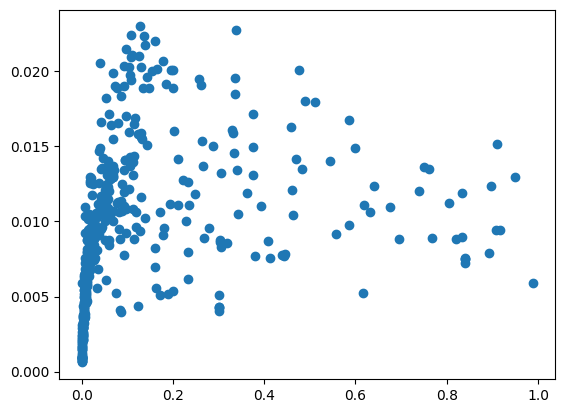

(0.0, 0.05)

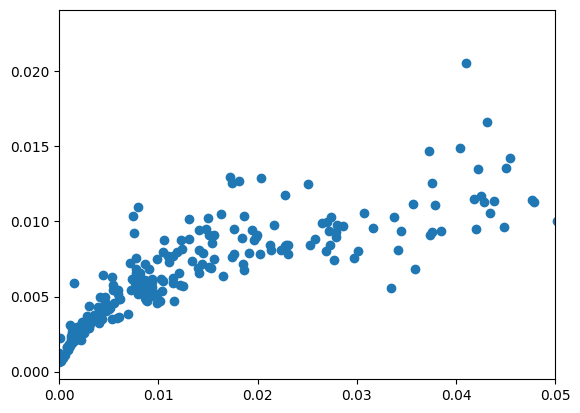

In [15]:
plt.plot(data.mean(axis=0), reco_err_var, 'o')
plt.show()

plt.plot(data.mean(axis=0), reco_err_var, 'o')
plt.xlim(0,0.05)

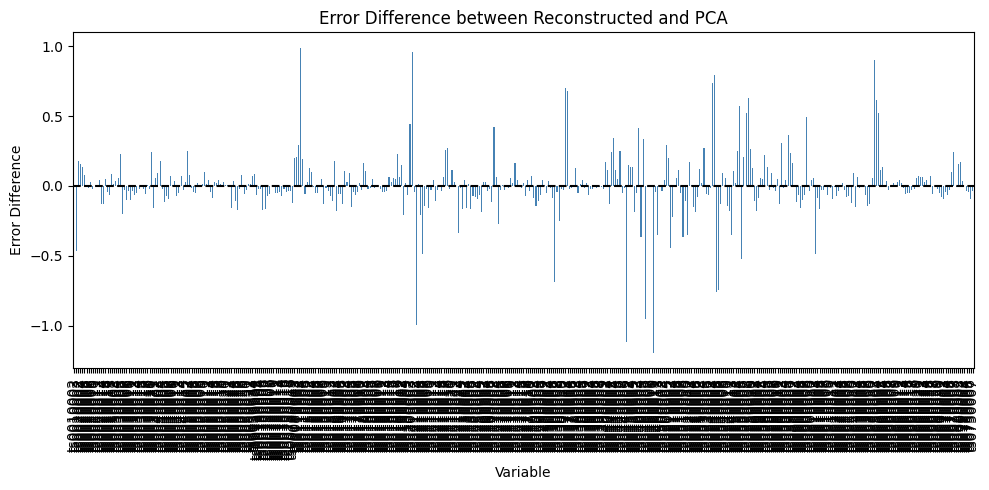

Top 10 Variables with the Highest Error Difference:
ts0110003    0.991444
ts0200003    0.959387
ts0650002    0.906034
ts0540004    0.793229
ts0540003    0.737570
ts0370002    0.702681
ts0370003    0.678513
ts0550008    0.632297
ts0650003    0.616447
ts0550004    0.574923
dtype: float64
Bottom 10 Variables with the Lowest Error Difference:
ts0460010   -1.194738
ts0440009   -1.115288
ts0210003   -0.993298
ts0460006   -0.951146
ts0540005   -0.757686
ts0540006   -0.742076
ts0300006   -0.686331
ts0550005   -0.526595
ts0610003   -0.485505
ts0210006   -0.484017
dtype: float64


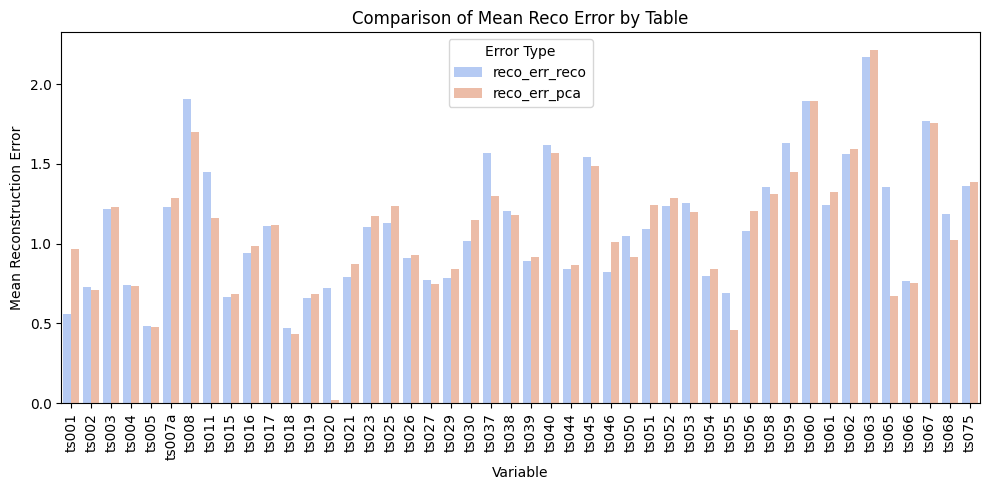

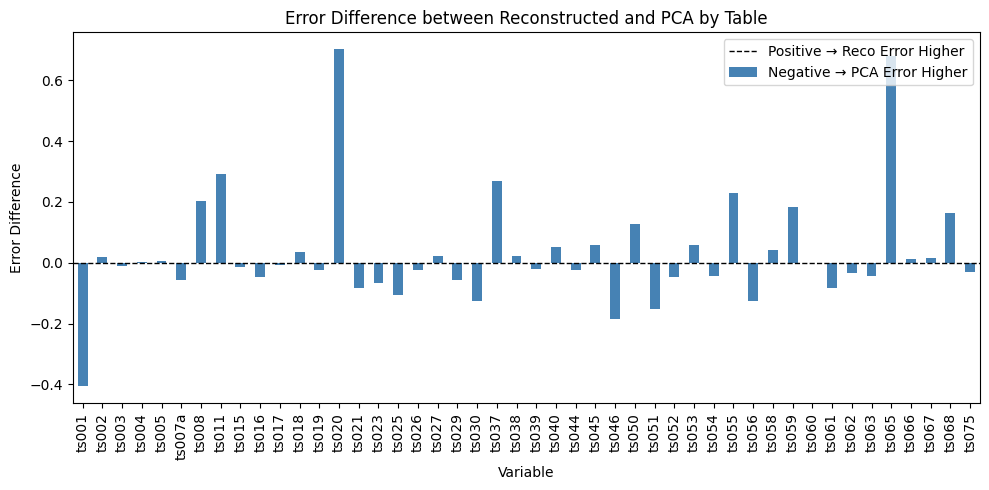

/tmp/ipykernel_1349/1087736486.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="Category", y="Error Difference", data=category_error, palette="coolwarm")


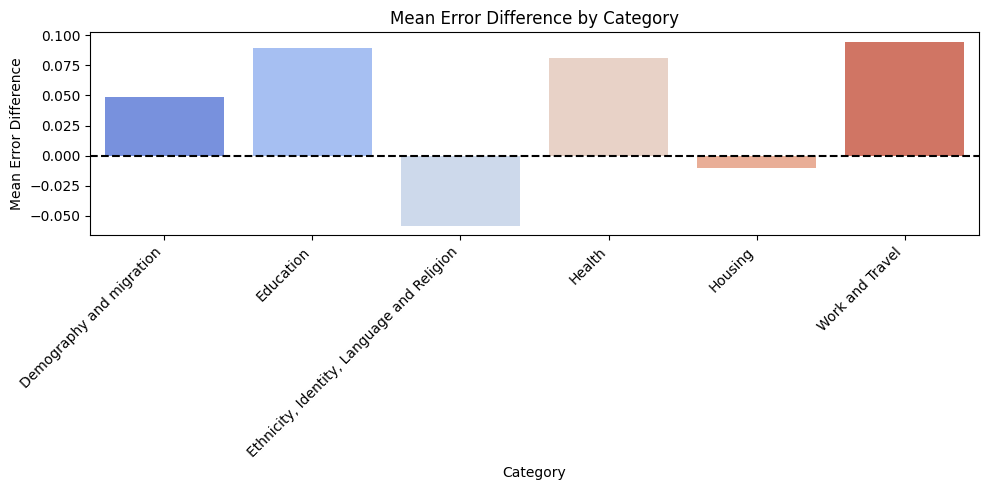

In [3]:
# Compute absolute reconstruction errors
reco_err_var = np.abs(data - reco_data).mean(axis=0)
pca_reco_err_var = np.abs(data - pca_reco).mean(axis=0)

# Normalize the errors
reco_err_var /= reco_err_var.mean()
pca_reco_err_var /= pca_reco_err_var.mean()

# Drop "_PCT" from column names
reco_err_var.index = reco_err_var.index.str.replace("_PCT", "")
pca_reco_err_var.index = pca_reco_err_var.index.str.replace("_PCT", "")

# Compute error difference
error_diff = reco_err_var - pca_reco_err_var

# Plot error differences
plt.figure(figsize=(10, 5))
error_diff.plot(kind='bar', color='steelblue')
plt.xlabel("Variable")
plt.ylabel("Error Difference")
plt.title("Error Difference between Reconstructed and PCA")
plt.axhline(0, color='black', linestyle='dashed')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Print top 10 variables with the highest error difference
top_10 = error_diff.nlargest(10)
print("Top 10 Variables with the Highest Error Difference:")
print(top_10)

# Print bottom 10 variables with the lowest error difference
bottom_10 = error_diff.nsmallest(10)
print("Bottom 10 Variables with the Lowest Error Difference:")
print(bottom_10)

# Drop last 4 characters from index for table-based analysis
reco_err_var.index = reco_err_var.index.str[:-4]
pca_reco_err_var.index = pca_reco_err_var.index.str[:-4]

# Group by table and compute mean errors
reco_err_var = reco_err_var.groupby(reco_err_var.index).mean()
pca_reco_err_var = pca_reco_err_var.groupby(pca_reco_err_var.index).mean()

# Create a DataFrame for grouped errors
grouped_table = pd.DataFrame({"reco_err_reco": reco_err_var, "reco_err_pca": pca_reco_err_var})
error_diff = reco_err_var - pca_reco_err_var

# Convert to long format for seaborn
grouped_table_long = grouped_table.reset_index().melt(id_vars=["index"], 
                                                      var_name="Error Type", 
                                                      value_name="Mean Reco Error")

# Plot grouped error comparison
plt.figure(figsize=(10, 5))
ax = sns.barplot(x="index", y="Mean Reco Error", hue="Error Type", data=grouped_table_long, palette="coolwarm")
plt.xlabel("Variable")
plt.ylabel("Mean Reconstruction Error")
plt.title("Comparison of Mean Reco Error by Table")
plt.legend(title="Error Type")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Plot error difference by table
plt.figure(figsize=(10, 5))
ax = error_diff.plot(kind='bar', color='steelblue')
plt.axhline(0, color='black', linewidth=1, linestyle='dashed')
plt.xlabel("Variable")
plt.ylabel("Error Difference")
plt.title("Error Difference between Reconstructed and PCA by Table")
plt.legend(["Positive → Reco Error Higher", "Negative → PCA Error Higher"], loc="upper right", frameon=True)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Load category mapping
cat = pd.read_csv("../data/Category.csv")

# Reset index and merge with category information
error_diff_df = error_diff.reset_index()
error_diff_df.columns = ["Table", "Error Difference"]
merged_df = error_diff_df.merge(cat, on="Table", how="left")

# Group by category and compute mean error difference
category_error = merged_df.groupby("Category")["Error Difference"].mean().reset_index()

# Plot mean error difference by category
plt.figure(figsize=(10, 5))
ax = sns.barplot(x="Category", y="Error Difference", data=category_error, palette="coolwarm")
plt.axhline(0, color='black', linestyle='dashed')
plt.xlabel("Category")
plt.ylabel("Mean Error Difference")
plt.title("Mean Error Difference by Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [4]:
reco_err_var

ts001     0.562114
ts002     0.730702
ts003     1.217106
ts004     0.739394
ts005     0.483449
ts007a    1.229159
ts008     1.907374
ts011     1.451731
ts015     0.666955
ts016     0.938900
ts017     1.109166
ts018     0.468842
ts019     0.658095
ts020     0.721467
ts021     0.789874
ts023     1.106509
ts025     1.130929
ts026     0.907678
ts027     0.773735
ts029     0.783270
ts030     1.019780
ts037     1.565871
ts038     1.205788
ts039     0.893398
ts040     1.620360
ts044     0.843424
ts045     1.544590
ts046     0.824585
ts050     1.046349
ts051     1.092454
ts052     1.237839
ts053     1.256846
ts054     0.799498
ts055     0.690463
ts056     1.080080
ts058     1.354952
ts059     1.630675
ts060     1.892832
ts061     1.243130
ts062     1.559649
ts063     2.172351
ts065     1.356309
ts066     0.766487
ts067     1.772384
ts068     1.186924
ts075     1.359657
dtype: float64